In [1]:
# nibabel: leer archivos .nii (MRI). El resto son las librerías clásicas
# de procesamiento de imágenes que se vieron en clase.
get_ipython().system('pip install nibabel scikit-image scikit-learn scipy matplotlib numpy -q')

In [2]:
import numpy as np                     # cálculo numérico (arrays)
import matplotlib.pyplot as plt        # visualización
import nibabel as nib                  # lectura de MRI .nii
from scipy import ndimage as ndi       # etiquetado, relleno, distancia

# Filtros y mejora (dominio espacial)
from skimage.filters import threshold_otsu, median, gaussian, sobel
from skimage.exposure import equalize_hist          # ecualización de histograma

# Morfología matemática
from skimage.morphology import disk, opening, closing, medial_axis
# disk = elemento estructurante circular; opening=apertura; closing=cierre
# medial_axis = esqueletización + transformada de distancia (espesor)

# Textura (GLCM / Haralick) y bordes (Canny)
from skimage.feature import graycomatrix, graycoprops, canny

# Clusterización K-means para segmentar tejidos
from sklearn.cluster import KMeans

# Paleta de estilo "oscuro" para que los gráficos se vean profesionales
BG_FIG  = '#0d1117'   # fondo de la figura
BG_AX   = '#161b22'   # fondo del área de ejes
FG_TXT  = 'white'     # color de texto
C_CSF, C_GM, C_WM, C_TEJ = '#4A90D9', '#5CB85C', '#E74C3C', '#A29BFE'

def estilo_oscuro(ax):
    """Aplica el look oscuro del notebook anterior a un eje."""
    ax.set_facecolor(BG_AX)
    ax.tick_params(colors=FG_TXT)
    for lado in ['top', 'right']:
        ax.spines[lado].set_visible(False)
    for s in ax.spines.values():
        s.set_edgecolor('#444')
    ax.xaxis.label.set_color(FG_TXT)
    ax.yaxis.label.set_color(FG_TXT)



In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


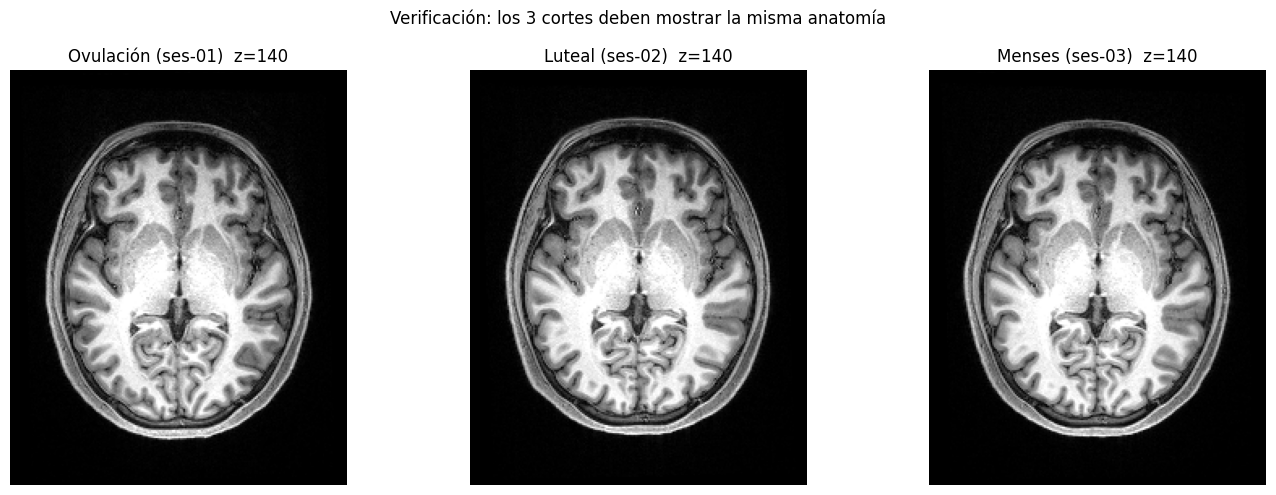

Si los 3 cortes se ven a la misma altura, podemos seguir.


In [7]:

# Cargar un volumen y extraer UN CORTE 2D representativo

# Trabajamos en 2D: en lugar de procesar el volumen entero (3D),
# tomamos un único corte axial que muestre bien corteza + ventrículos.
# IMPORTANTE: el corte debe estar al MISMO nivel anatómico en las 3
# sesiones para que la comparación tenga sentido (lo verificamos visualmente).

def cargar_corte(path, z_rel=0.55):
    """Carga un .nii y devuelve un corte axial 2D + el tamaño de píxel en mm.
       z_rel: posición relativa del corte en el eje Z (0=base, 1=tope).
       0.55 cae aproximadamente a la altura de los ventrículos laterales."""
    img = nib.load(path)                       # abre el archivo .nii
    data = img.get_fdata()                     # array 3D de intensidades
    zooms = img.header.get_zooms()             # tamaño de vóxel (mm) por eje
    px_mm = zooms[0] * zooms[1]                 # área de un píxel del corte (mm²)
    z = int(data.shape[2] * z_rel)             # índice del corte axial elegido
    corte = data[:, :, z]                       # extrae el plano 2D (eje Z fijo)
    return corte, px_mm, z

# Rutas a las 3 sesiones (ajustá si tus nombres difieren)
sesiones = [
    ('/content/drive/MyDrive/ITBA/1C 2026/16.63-PSIB/TP/TPI/sub-34_ses-01_T1w.nii', 'Ovulación', 'ses-01'),
    ('/content/drive/MyDrive/ITBA/1C 2026/16.63-PSIB/TP/TPI/sub-34_ses-02_T1w.nii', 'Luteal',    'ses-02'),
    ('/content/drive/MyDrive/ITBA/1C 2026/16.63-PSIB/TP/TPI/sub-34_ses-03_T1w.nii', 'Menses',    'ses-03'),
]

# Vista previa de los 3 cortes para verificar que están al mismo nivel
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (path, fase, sid) in zip(axes, sesiones):
    corte, px_mm, z = cargar_corte(path)
    # Percentiles 2-98 para mejorar el contraste visual (no altera los datos)
    vmin, vmax = np.percentile(corte, [2, 98])
    ax.imshow(corte.T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f'{fase} ({sid})  z={z}')
    ax.axis('off')
plt.suptitle('Verificación: los 3 cortes deben mostrar la misma anatomía')
plt.tight_layout(); plt.show()
print("Si los 3 cortes se ven a la misma altura, podemos seguir.")

El corte se toma en la posición relativa z_rel=0.55 (55% del eje Z), que cae aproximadamente a la altura de los ventrículos laterales. También extrae el tamaño de píxel en mm² para calcular áreas reales luego.

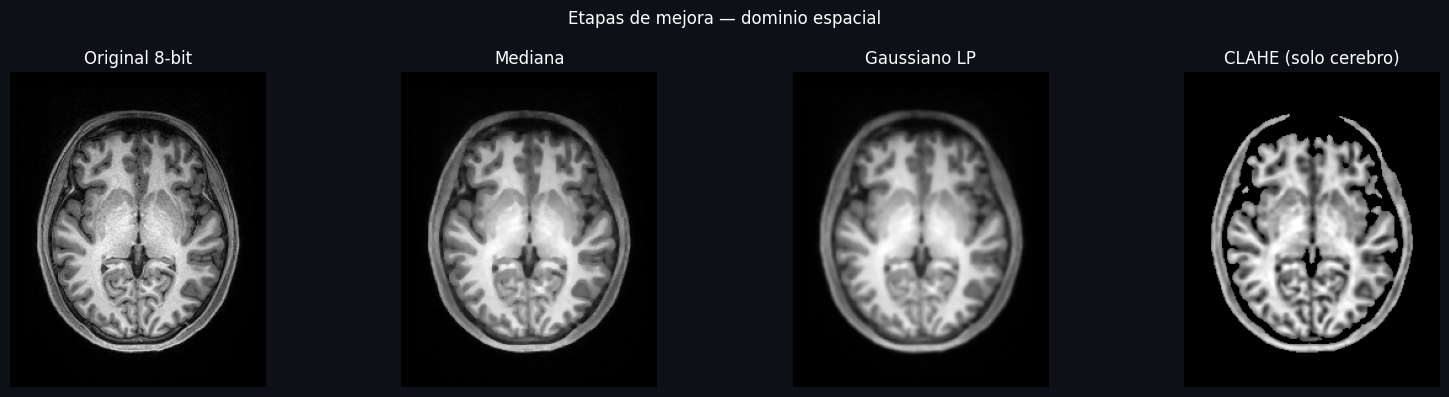

Mejora aplicada. Para SEGMENTAR usamos img_g (CLAHE es solo realce visual).


In [13]:
#  Mejora de imagen (filtrado en dominio espacial)

# Cadena de mejora:
#   1) escalar a 8 bits (0-255) para trabajar con intensidades estándar
#   2) filtro de mediana    -> elimina ruido impulsivo (sal y pimienta)
#   3) filtro gaussiano LP   -> suaviza y atenúa altas frecuencias (ruido)
#   4) CLAHE (solo cerebro)  -> realce de contraste LOCAL y limitado

from skimage.exposure import equalize_adapthist

# Por qué CLAHE y no equalize_hist global:
#   La ecualización global aplana el histograma bimodal de la RM, pierde el
#   contraste natural GM/WM y amplifica el ruido en zonas homogéneas (se ve
#   peor que la original). CLAHE trabaja por regiones (tiles) y limita cuánto
#   puede amplificar el contraste -> realza estructuras sin reventar el ruido.

def mejorar(corte):
    """Escalado + mediana + gaussiano + CLAHE (sobre el cerebro)."""
    rango = np.ptp(corte)
    img8 = ((corte - corte.min()) / (rango + 1e-9) * 255).astype(np.uint8)

    img_med = median(img8, disk(2))                              # ruido impulsivo
    img_g = (gaussian(img_med, sigma=1) * 255).astype(np.uint8)  # gaussiano LP

    # Máscara de primer plano (cerebro+cabeza) para no procesar el fondo.
    fg = img_g > threshold_otsu(img_g)

    # CLAHE: clip_limit bajo = realce suave y controlado; kernel_size define
    # el tamaño de las regiones locales. Aplicado sobre toda la imagen y
    # luego enmascarado para dejar el fondo en negro.
    img_clahe = equalize_adapthist(img_g, kernel_size=8, clip_limit=0.02)
    img_clahe = (img_clahe * 255).astype(np.uint8)
    img_clahe[~fg] = 0                                           # fondo en negro

    return img8, img_med, img_g, img_clahe

corte0, px_mm0, _ = cargar_corte(sesiones[0][0])
img8, img_med, img_g, img_clahe = mejorar(corte0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor=BG_FIG)
for ax, im, t in zip(axes,
                     [img8, img_med, img_g, img_clahe],
                     ['Original 8-bit', 'Mediana', 'Gaussiano LP',
                      'CLAHE (solo cerebro)']):
    ax.imshow(im.T, cmap='gray', origin='lower'); ax.set_title(t, color=FG_TXT)
    ax.axis('off')
plt.suptitle('Etapas de mejora — dominio espacial', color=FG_TXT)
plt.tight_layout(); plt.show()

print("Mejora aplicada. Para SEGMENTAR usamos img_g (CLAHE es solo realce visual).")
# Nota: para segmentar seguimos usando img_g (suavizada, SIN realce de contraste),
# porque CLAHE -como cualquier ecualización- distorsiona las intensidades
# relativas entre CSF/GM/WM de las que dependen Otsu/k-means.

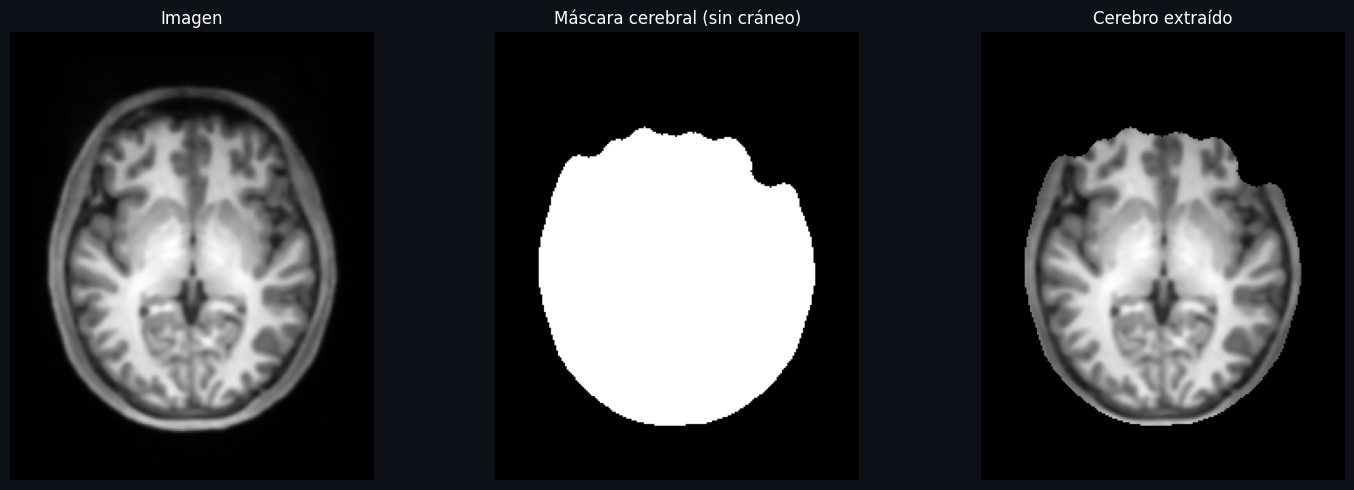

Cerebro extraído (skull stripping). Bounding box (x0,y0,x1,y1) = (np.int64(31), np.int64(25), np.int64(201), np.int64(182))


In [28]:
#  Extracción del CEREBRO en 2D (skull stripping morfológico)

# Objetivo: quedarnos SOLO con el tejido cerebral (GM/WM/CSF interno),
# sin cráneo ni cuero cabelludo, para que Otsu/k-means de la segmentación
# posterior no metan hueso/grasa como si fueran tejido.
#
# Idea (erosión -> componente mayor -> dilatación):
#   En una T1 axial, cerebro y scalp quedan unidos por "puentes" finos.
#   Una erosión con disco grande ROMPE esos puentes; el cerebro (la masa
#   más compacta) sobrevive como componente más grande, y el scalp queda
#   desconectado y se descarta. Luego dilatamos lo mismo que erosionamos
#   para recuperar el borde real del cerebro.

from skimage.morphology import erosion, dilation, disk, opening, closing

def extraer_cerebro(img_g, r_corte=10):
    """Otsu -> limpieza -> erosión fuerte -> componente mayor ->
       dilatación equivalente -> relleno. Devuelve la máscara del cerebro."""
    # 1) Primer plano (cabeza completa)
    thr = threshold_otsu(img_g)
    mask = img_g > thr
    mask = opening(mask, disk(2))             # borra motas chicas
    mask = closing(mask, disk(3))             # cierra cortes finos
    mask = ndi.binary_fill_holes(mask)

    # 2) Desconectar el cerebro del cuero cabelludo / cráneo.
    #    'r_corte' controla cuán agresivo es el corte de los puentes.
    nucleo = erosion(mask, disk(r_corte))

    # 3) Quedarnos con el núcleo cerebral (componente conexo más grande).
    lab, _ = ndi.label(nucleo)
    sizes = np.bincount(lab.ravel()); sizes[0] = 0
    if sizes.size <= 1:                       # por si la erosión borró todo
        raise ValueError("Erosión demasiado fuerte: bajá r_corte.")
    nucleo = (lab == sizes.argmax())

    # 4) Recuperar el borde del cerebro dilatando lo mismo que erosionamos,
    #    pero limitando el resultado a la cabeza original (no inventar borde).
    cerebro = dilation(nucleo, disk(r_corte-3))
    cerebro = cerebro & mask                  # no excederse de la cabeza
    cerebro = closing(cerebro, disk(4))       # suaviza el contorno
    cerebro = ndi.binary_fill_holes(cerebro)  # rellena surcos/ventrículos
    return cerebro

mask0 = extraer_cerebro(img_g)
ys, xs = np.where(mask0)
bbox = (xs.min(), ys.min(), xs.max(), ys.max())

# Cerebro extraído: aplicamos la máscara a la imagen para segmentar SOLO dentro.
cerebro_img = np.where(mask0, img_g, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG_FIG)
axes[0].imshow(img_g.T,       cmap='gray', origin='lower'); axes[0].set_title('Imagen', color=FG_TXT)
axes[1].imshow(mask0.T,       cmap='gray', origin='lower'); axes[1].set_title('Máscara cerebral (sin cráneo)', color=FG_TXT)
axes[2].imshow(cerebro_img.T, cmap='gray', origin='lower'); axes[2].set_title('Cerebro extraído', color=FG_TXT)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print(f"Cerebro extraído (skull stripping). Bounding box (x0,y0,x1,y1) = {bbox}")

Silhouette score: 0.553


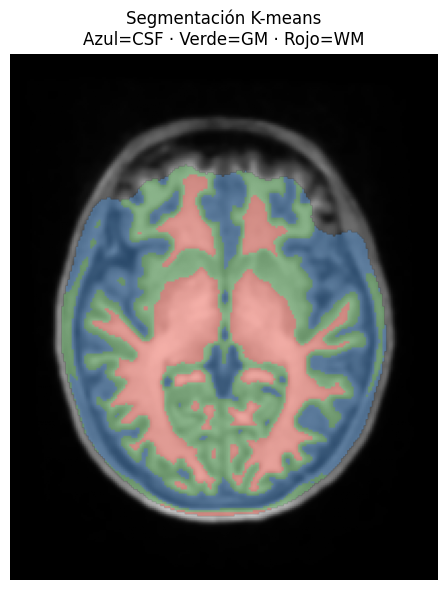

In [37]:
# Segmentación de tejidos por K-means (CSF / GM / WM)

# Dentro de la máscara, agrupamos los píxeles en 3 clases por intensidad.
# K-means clusteriza por cercanía a centroides, pero asigna las etiquetas
# en orden ARBITRARIO. Por eso ordenamos los centroides de menor a mayor
# intensidad y remapeamos: en T1 vale CSF < GM < WM.


from sklearn.metrics import silhouette_score

def segmentar_tejidos(img_g, mask):
    """K-means de 3 clases dentro de la máscara. Devuelve seg con 1=CSF,2=GM,3=WM."""
    px = img_g[mask].reshape(-1, 1).astype(float)        # vector de intensidades
    km = KMeans(n_clusters=3, n_init=5, random_state=0).fit(px)

#3 clusters (CSF, GM, WM) basados en intensidad de píxeles. El silhouette score te dice si esas 3 clases quedaron bien separadas en intensidad o si hay mucha superposición entre, por ejemplo, GM y WM.
#Un score de 0.6 o más para imágenes T1 sería una buena señal. Valores entre 0.3–0.5 son típicos y aceptables dado que GM y WM naturalmente se solapan un poco en intensidad.
    px_sample = px[::10]  # subsample para que no tarde mucho
    labels_sample = km.predict(px_sample)
    score = silhouette_score(px_sample, labels_sample)
    print(f"Silhouette score: {score:.3f}")

    # Ordenar clusters por intensidad del centroide (menor -> mayor).
    orden = np.argsort(km.cluster_centers_.ravel())      # ej: [2,0,1]
    # remap[label_original] = clase_ordenada (0=CSF, 1=GM, 2=WM)
    remap = np.zeros_like(orden)
    remap[orden] = np.arange(3)

    # Reconstruir la imagen etiquetada: 0=fondo, 1=CSF, 2=GM, 3=WM.
    seg = np.zeros(img_g.shape, dtype=np.uint8)
    seg[mask] = remap[km.labels_] + 1                    # +1 -> 1,2,3
    return seg

seg0 = segmentar_tejidos(img_g, mask0)

# QC visual: superponemos colores sobre la imagen (azul=CSF, verde=GM, rojo=WM)
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['black', '#4A90D9', '#5CB85C', '#E74C3C'])
overlay = np.ma.masked_where(seg0 == 0, seg0)
plt.figure(figsize=(6, 6))
plt.imshow(img_g.T, cmap='gray', origin='lower')
plt.imshow(overlay.T, cmap=cmap, origin='lower', alpha=0.45, vmin=0, vmax=3)
plt.title('Segmentación K-means\nAzul=CSF · Verde=GM · Rojo=WM'); plt.axis('off')
plt.tight_layout(); plt.show()

In [38]:

# Métricas: "volumen" 2D (área) y espesor cortical (proxy)

# En 2D el "volumen" se mide como ÁREA = (nº de píxeles) × (área de píxel mm²).
# Es un proxy del volumen 3D, válido si comparamos el mismo corte entre fases.
#
# Espesor cortical (proxy morfológico): sobre la cinta de GM aplicamos
# medial_axis (esqueleto + transformada de distancia). La distancia en cada
# punto del esqueleto es el "radio" local; el espesor ≈ 2 × radio.

def medir(seg, px_mm):
    """Devuelve áreas (mm²) y espesor cortical proxy (mm)."""
    a_csf = (seg == 1).sum() * px_mm
    a_gm  = (seg == 2).sum() * px_mm
    a_wm  = (seg == 3).sum() * px_mm
    a_tej = a_gm + a_wm                      # tejido = GM + WM
    a_tot = a_tej + a_csf                    # total = tejido + CSF

    gm_mask = (seg == 2)                     # cinta cortical (materia gris)
    skel, dist = medial_axis(gm_mask, return_distance=True)
    lado_mm = np.sqrt(px_mm)                 # tamaño lineal aprox. de un píxel
    espesores = dist[skel] * 2 * lado_mm     # diámetro local en mm
    ct = float(espesores.mean()) if espesores.size else 0.0

    return dict(a_csf=a_csf, a_gm=a_gm, a_wm=a_wm, a_tej=a_tej,
                a_tot=a_tot, ct_mm=ct)

m0 = medir(seg0, px_mm0)
print("Sesión 1:", {k: round(v, 2) for k, v in m0.items()})



Sesión 1: {'a_csf': np.float64(6359.93), 'a_gm': np.float64(7012.12), 'a_wm': np.float64(5311.3), 'a_tej': np.float64(12323.42), 'a_tot': np.float64(18683.35), 'ct_mm': 4.59}


In [39]:

# Textura GLCM / Haralick sobre la materia gris

# Caracterizamos la "rugosidad" de la corteza con la matriz de co-ocurrencia
# de niveles de gris (GLCM) y atributos de Haralick. Se calcula en las 4
# direcciones (0,45,90,135°) y se promedia para que sea rotacionalmente estable.

def textura_gm(img_g, seg, niveles=32):
    """Atributos de Haralick (contraste, energía, homogeneidad, correlación) en GM."""
    gm_mask = (seg == 2)
    roi = img_g.copy()
    roi[~gm_mask] = 0
    # Recuantizar a 'niveles' grises (la GLCM crece con el cuadrado de niveles)
    roi_q = (roi / (roi.max() + 1e-9) * (niveles - 1)).astype(np.uint8)
    glcm = graycomatrix(roi_q, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=niveles, symmetric=True, normed=True)
    props = ['contrast', 'energy', 'homogeneity', 'correlation']
    return {p: float(graycoprops(glcm, p).mean()) for p in props}

t0 = textura_gm(img_g, seg0)
print("Textura GM sesión 1:", {k: round(v, 3) for k, v in t0.items()})



Textura GM sesión 1: {'contrast': 29.913, 'energy': 0.827, 'homogeneity': 0.887, 'correlation': 0.818}


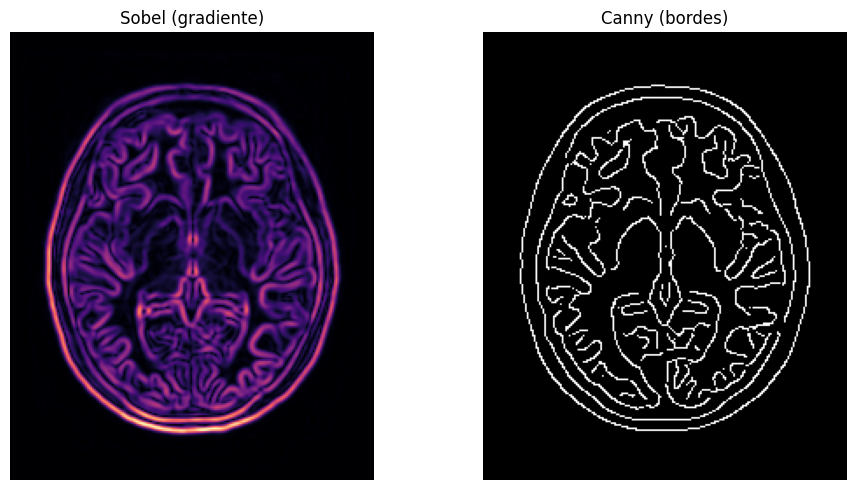

Bordes detectados (solo visualización).


In [40]:

# Detección de bordes (Sobel / Canny) — visualización

# Resalta las fronteras corticales. Sobel = gradiente (1ª derivada);
# Canny = gradiente + supresión de no-máximos + umbral por histéresis.
g_sobel = sobel(img_g / 255.0)
g_canny = canny(img_g / 255.0, sigma=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(g_sobel.T, cmap='magma', origin='lower'); axes[0].set_title('Sobel (gradiente)')
axes[1].imshow(g_canny.T, cmap='gray', origin='lower'); axes[1].set_title('Canny (bordes)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print("Bordes detectados (solo visualización).")


In [41]:

# Procesar las 3 sesiones y comparar entre fases

# Unimos todo: para cada sesión corremos la cadena completa y guardamos
# las métricas. Luego graficamos la comparación entre fases.

import pandas as pd

# Hormonas reales de sub-34 (de sessions.tsv) para contexto del gráfico
hormonas = {'ses-01': dict(E2=480.0, P4=1.4,  LH=81.95, FSH=15.38),
            'ses-02': dict(E2=260.0, P4=20.0, LH=6.16,  FSH=2.39),
            'ses-03': dict(E2=25.0,  P4=0.18, LH=5.16,  FSH=7.32)}

filas = []
for path, fase, sid in sesiones:
    corte, px_mm, z = cargar_corte(path)            # 1) corte 2D
    _, _, img_g, _ = mejorar(corte)                 # 2) mejora
    mask = extraer_cerebro(img_g)                   # 3) cerebro
    seg = segmentar_tejidos(img_g, mask)            # 4) tejidos
    met = medir(seg, px_mm)                          # 5) áreas + espesor
    tex = textura_gm(img_g, seg)                     # 6) textura
    fila = dict(session=sid, phase=fase, **hormonas[sid], **met,
                contrast=tex['contrast'], energy=tex['energy'],
                homogeneity=tex['homogeneity'])
    filas.append(fila)
    print(f"{fase} ({sid}) procesada")

df = pd.DataFrame(filas)
# Ordenar por ciclo natural: Menses -> Ovulación -> Luteal
orden = ['ses-03', 'ses-01', 'ses-02']
df = df.set_index('session').loc[orden].reset_index()
print("\n=== TABLA COMPARATIVA ENTRE FASES ===")
print(df.to_string(index=False))



Silhouette score: 0.553
Ovulación (ses-01) procesada
Silhouette score: 0.553
Luteal (ses-02) procesada
Silhouette score: 0.547
Menses (ses-03) procesada

=== TABLA COMPARATIVA ENTRE FASES ===
session     phase    E2    P4    LH   FSH       a_csf        a_gm        a_wm        a_tej        a_tot    ct_mm  contrast   energy  homogeneity
 ses-03    Menses  25.0  0.18  5.16  7.32 5831.634983 6954.600810 5748.452330 12703.053139 18534.688123 4.633345 29.229773 0.828685     0.889930
 ses-01 Ovulación 480.0  1.40 81.95 15.38 6359.933327 7012.120730 5311.300936 12323.421666 18683.354993 4.584407 29.913449 0.826915     0.886942
 ses-02    Luteal 260.0 20.00  6.16  2.39 4673.272283 6765.227534 6406.834185 13172.061719 17845.334002 4.418732 30.408819 0.831884     0.888896


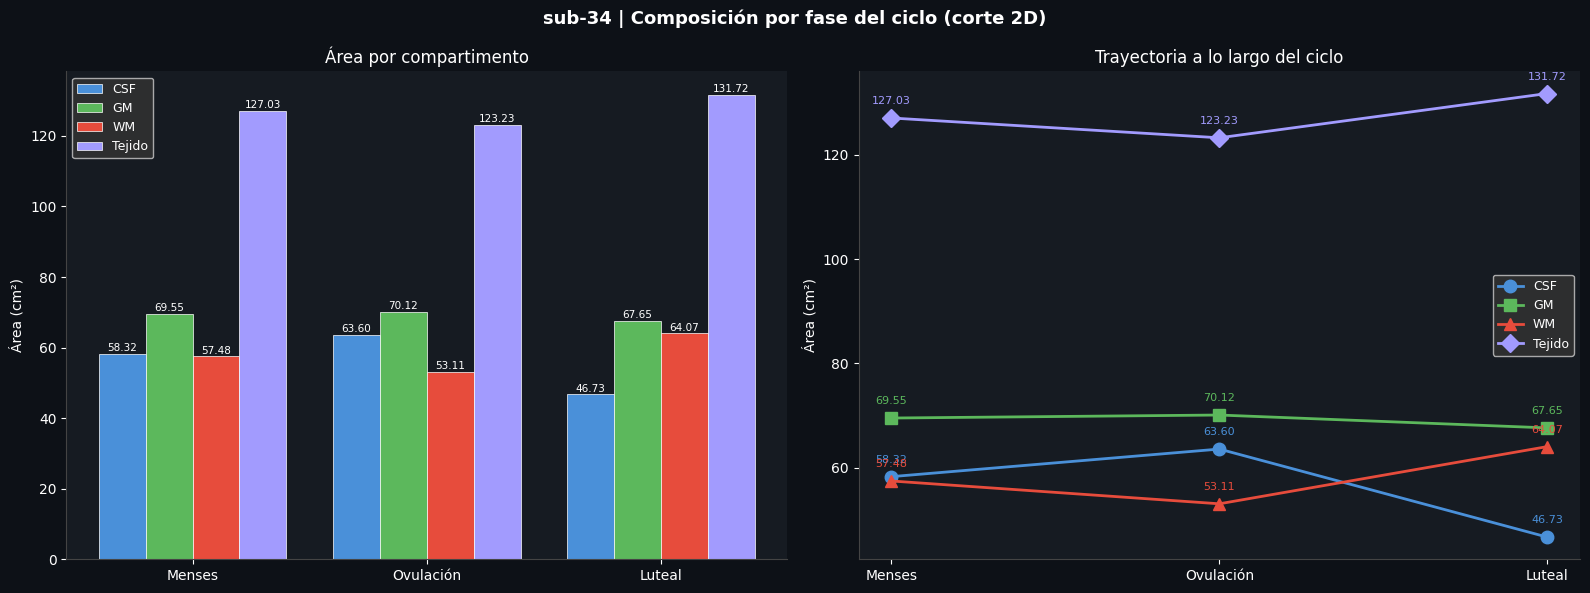

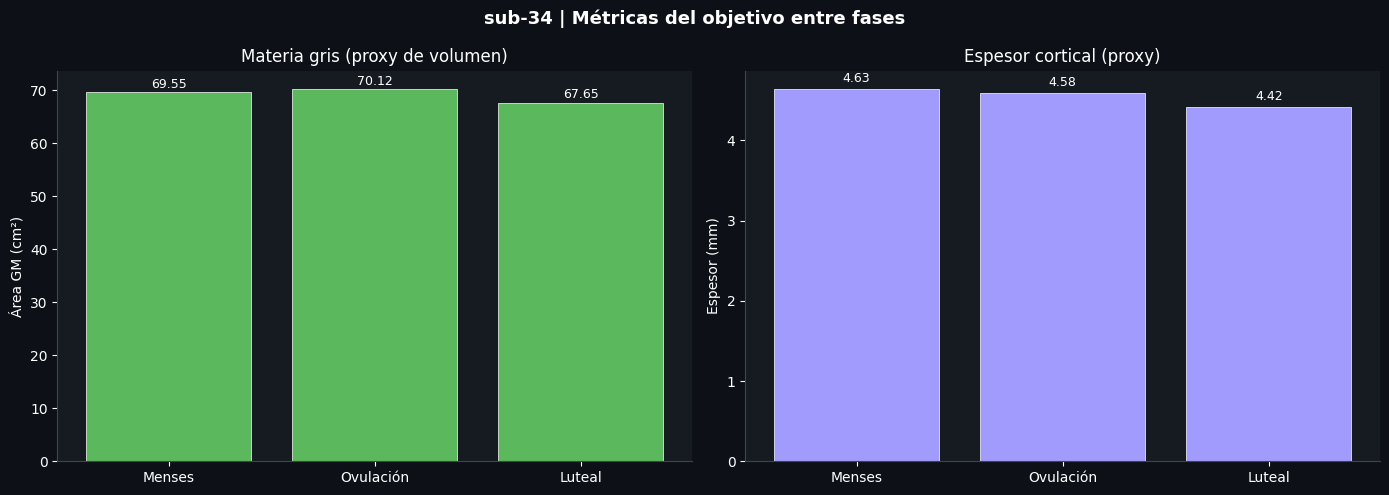

Análisis completo.

RECORDATORIO: con n=1 sujeto y 3 fases esto es DESCRIPTIVO, no
estadístico. Presentalo como ejemplo trabajado / prueba de método.


In [45]:
# FIGURA A: composición por fase (barras + trayectoria)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_FIG)
fig.suptitle('sub-34 | Composición por fase del ciclo (corte 2D)',
             color=FG_TXT, fontsize=13, fontweight='bold')

# Convertir a cm²
csf_cm = csf_v / 100; gm_cm = gm_v / 100
wm_cm  = wm_v  / 100; tej_cm = tej_v / 100

# Panel izq: barras agrupadas por compartimento
ax1 = axes[0]; estilo_oscuro(ax1); w = 0.2
for i, (vals, c, lab) in enumerate([(csf_cm, C_CSF, 'CSF'), (gm_cm, C_GM, 'GM'),
                                    (wm_cm, C_WM, 'WM'), (tej_cm, C_TEJ, 'Tejido')]):
    barras = ax1.bar(x + (i - 1.5) * w, vals, w, label=lab,
                     color=c, edgecolor='white', linewidth=0.5)
    for b in barras:
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
                 f'{b.get_height():.2f}', ha='center', va='bottom',
                 color=FG_TXT, fontsize=7.5)
ax1.set_xticks(x); ax1.set_xticklabels(fases)
ax1.set_ylabel('Área (cm²)'); ax1.set_title('Área por compartimento', color=FG_TXT)
ax1.legend(facecolor='#333', labelcolor=FG_TXT, fontsize=9)

# Panel der: trayectoria a lo largo del ciclo
ax2 = axes[1]; estilo_oscuro(ax2)
for vals, c, mk, lab in [(csf_cm, C_CSF, 'o', 'CSF'), (gm_cm, C_GM, 's', 'GM'),
                         (wm_cm, C_WM, '^', 'WM'), (tej_cm, C_TEJ, 'D', 'Tejido')]:
    ax2.plot(x, vals, color=c, linewidth=2, marker=mk, markersize=9, label=lab)
    for xi, v in zip(x, vals):
        ax2.annotate(f'{v:.2f}', (xi, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', color=c, fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(fases)
ax2.set_ylabel('Área (cm²)'); ax2.set_title('Trayectoria a lo largo del ciclo', color=FG_TXT)
ax2.legend(facecolor='#333', labelcolor=FG_TXT, fontsize=9)
plt.tight_layout(); plt.show()

# FIGURA B: métricas clave del objetivo (GM y espesor)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG_FIG)
fig.suptitle('sub-34 | Métricas del objetivo entre fases',
             color=FG_TXT, fontsize=13, fontweight='bold')

axb = axes[0]; estilo_oscuro(axb)
bb = axb.bar(x, gm_cm, color=C_GM, edgecolor='white', linewidth=0.5)
for b in bb: axb.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                      f'{b.get_height():.2f}', ha='center', va='bottom',
                      color=FG_TXT, fontsize=9)
axb.set_xticks(x); axb.set_xticklabels(fases)
axb.set_ylabel('Área GM (cm²)'); axb.set_title('Materia gris (proxy de volumen)', color=FG_TXT)

axc = axes[1]; estilo_oscuro(axc)  # espesor queda en mm, no se convierte
bc = axc.bar(x, ct_v, color=C_TEJ, edgecolor='white', linewidth=0.5)
for b in bc: axc.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                      f'{b.get_height():.2f}', ha='center', va='bottom',
                      color=FG_TXT, fontsize=9)
axc.set_xticks(x); axc.set_xticklabels(fases)
axc.set_ylabel('Espesor (mm)'); axc.set_title('Espesor cortical (proxy)', color=FG_TXT)
plt.tight_layout(); plt.show()

print("Análisis completo.")
print("\nRECORDATORIO: con n=1 sujeto y 3 fases esto es DESCRIPTIVO, no")
print("estadístico. Presentalo como ejemplo trabajado / prueba de método.")